# Tiny Dreamer Highway — Colab Sanity Run

**Name:** Esteban  
**Course:** CSC 580 AI 2  
**Assignment:** Final Project — Dream the Road  
**AI tools consulted:** GitHub Copilot

Use this notebook for a short Colab validation run before any longer training job.

## Runtime flow

1. Mount Google Drive.
2. Clone or pull the latest repository snapshot.
3. Install the package.
4. Run a short sanity job.
5. Confirm checkpoints, logs, overshooting metrics, and analysis artifacts are written.

In [10]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
REPO_URL = 'https://github.com/estmon8u/CSC_580_Final_Project.git'
DRIVE_ROOT = Path('/content/drive/MyDrive/CSC_580_Final_Project')
ARTIFACT_ROOT = DRIVE_ROOT / 'artifacts'
WORKTREE = Path('/content/CSC_580_Final_Project')

for path in [DRIVE_ROOT, ARTIFACT_ROOT, ARTIFACT_ROOT / 'training_runs']:
    path.mkdir(parents=True, exist_ok=True)

print('Drive root:', DRIVE_ROOT)
print('Artifact root:', ARTIFACT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive root: /content/drive/MyDrive/CSC_580_Final_Project
Artifact root: /content/drive/MyDrive/CSC_580_Final_Project/artifacts


In [11]:
%%bash
set -e
REPO_URL='https://github.com/estmon8u/CSC_580_Final_Project.git'
if [ ! -d /content/CSC_580_Final_Project/.git ]; then
  git clone "${REPO_URL}" /content/CSC_580_Final_Project
else
  cd /content/CSC_580_Final_Project
  git pull --ff-only origin main
fi

Already up to date.


From https://github.com/estmon8u/CSC_580_Final_Project
 * branch            main       -> FETCH_HEAD


In [12]:
%%bash
set -e
cd /content/CSC_580_Final_Project
python -m pip install --upgrade pip --quiet
python -m pip install -e . --quiet

In [13]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path('/content/CSC_580_Final_Project')
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from tiny_dreamer_highway.config import load_experiment_config
from tiny_dreamer_highway.training import run_training_experiment

CONFIG_PATH = PROJECT_ROOT / 'examples' / 'training_run.yaml'
config = load_experiment_config(CONFIG_PATH)
print('Loaded config from:', CONFIG_PATH)
print('Base cycles:', config.training.cycles)
print('Base batch size:', config.training.batch_size)

Loaded config from: /content/CSC_580_Final_Project/examples/training_run.yaml
Base cycles: 500
Base batch size: 32


In [14]:
RUN_NAME = 'sanity_check_001'
RUN_ARTIFACT_ROOT = ARTIFACT_ROOT / 'training_runs' / RUN_NAME
RUN_ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

CYCLES = 25
WARM_START_STEPS = 64
POLICY_STEPS = 8
CHECKPOINT_INTERVAL = 1
RESUME_FROM = None

print('Run name:', RUN_NAME)
print('Cycles:', CYCLES)
print('Warm-start steps:', WARM_START_STEPS)
print('Policy steps:', POLICY_STEPS)

Run name: sanity_check_001
Cycles: 25
Warm-start steps: 64
Policy steps: 8


In [15]:
print('Launching sanity run. Per-cycle progress lines will appear below.')

training_summary = run_training_experiment(
    config,
    RUN_ARTIFACT_ROOT,
    cycles=CYCLES,
    warm_start_steps=WARM_START_STEPS,
    policy_steps=POLICY_STEPS,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    resume_from=RESUME_FROM,
)

print('Completed cycles:', training_summary.completed_cycles)
print('Latest checkpoint:', training_summary.latest_checkpoint)
print('Latest metrics:', training_summary.latest_record)

Launching sanity run. Per-cycle progress lines will appear below.
[train] starting run | cycles=25 | start_step=1 | warm_start_steps=64 | policy_steps=8 | device=cuda
[train] step=1/25 | warm=64 | policy=8 | replay=72 | world_total=91.5515 | actor=0.1219 | critic=8.5032 | cycle_s=41.8 | elapsed_s=41.8 | checkpoint=checkpoint_00001.pt
[train] step=2/25 | warm=0 | policy=8 | replay=80 | world_total=53.9530 | actor=0.0588 | critic=8.5869 | cycle_s=5.6 | elapsed_s=47.4 | checkpoint=checkpoint_00002.pt
[train] step=3/25 | warm=0 | policy=8 | replay=88 | world_total=34.1343 | actor=0.1513 | critic=9.9419 | cycle_s=6.5 | elapsed_s=53.9 | checkpoint=checkpoint_00003.pt
[train] step=4/25 | warm=0 | policy=8 | replay=96 | world_total=30.2482 | actor=-0.1448 | critic=10.1596 | cycle_s=5.5 | elapsed_s=59.4 | checkpoint=checkpoint_00004.pt
[train] step=5/25 | warm=0 | policy=8 | replay=104 | world_total=27.0166 | actor=-0.0494 | critic=10.3000 | cycle_s=5.7 | elapsed_s=65.1 | checkpoint=checkpoint_

In [16]:
summary_path = training_summary.log_dir / 'latest_summary.json'
metrics_csv_path = training_summary.log_dir / 'cycle_metrics.csv'
metrics_jsonl_path = training_summary.log_dir / 'cycle_metrics.jsonl'
summary_payload = json.loads(summary_path.read_text(encoding='utf-8'))

print('Summary exists:', summary_path.exists())
print('CSV exists:', metrics_csv_path.exists())
print('JSONL exists:', metrics_jsonl_path.exists())
print('Checkpoint exists:', training_summary.latest_checkpoint is not None and training_summary.latest_checkpoint.exists())
summary_payload

Summary exists: True
CSV exists: True
JSONL exists: True
Checkpoint exists: True


{'checkpoint_file': '/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/sanity_check_001/checkpoints/checkpoint_00025.pt',
 'latest_metrics': {'behavior/actor_loss': 14.661839008331299,
  'behavior/critic_loss': 130.39808654785156,
  'behavior/imagined_reward_mean': -1.6854621767997742,
  'behavior/imagined_value_mean': -4.668254137039185,
  'policy_added': 8,
  'replay_size': 264,
  'step': 25,
  'warm_start_added': 0,
  'world_model/kl_loss': 3.3559677600860596,
  'world_model/kl_loss_raw': 3.1091485023498535,
  'world_model/reconstruction_loss': 0.09327700361609459,
  'world_model/reward_loss': 3.3481736183166504,
  'world_model/total_loss': 6.797418117523193},
 'latest_step': 25}

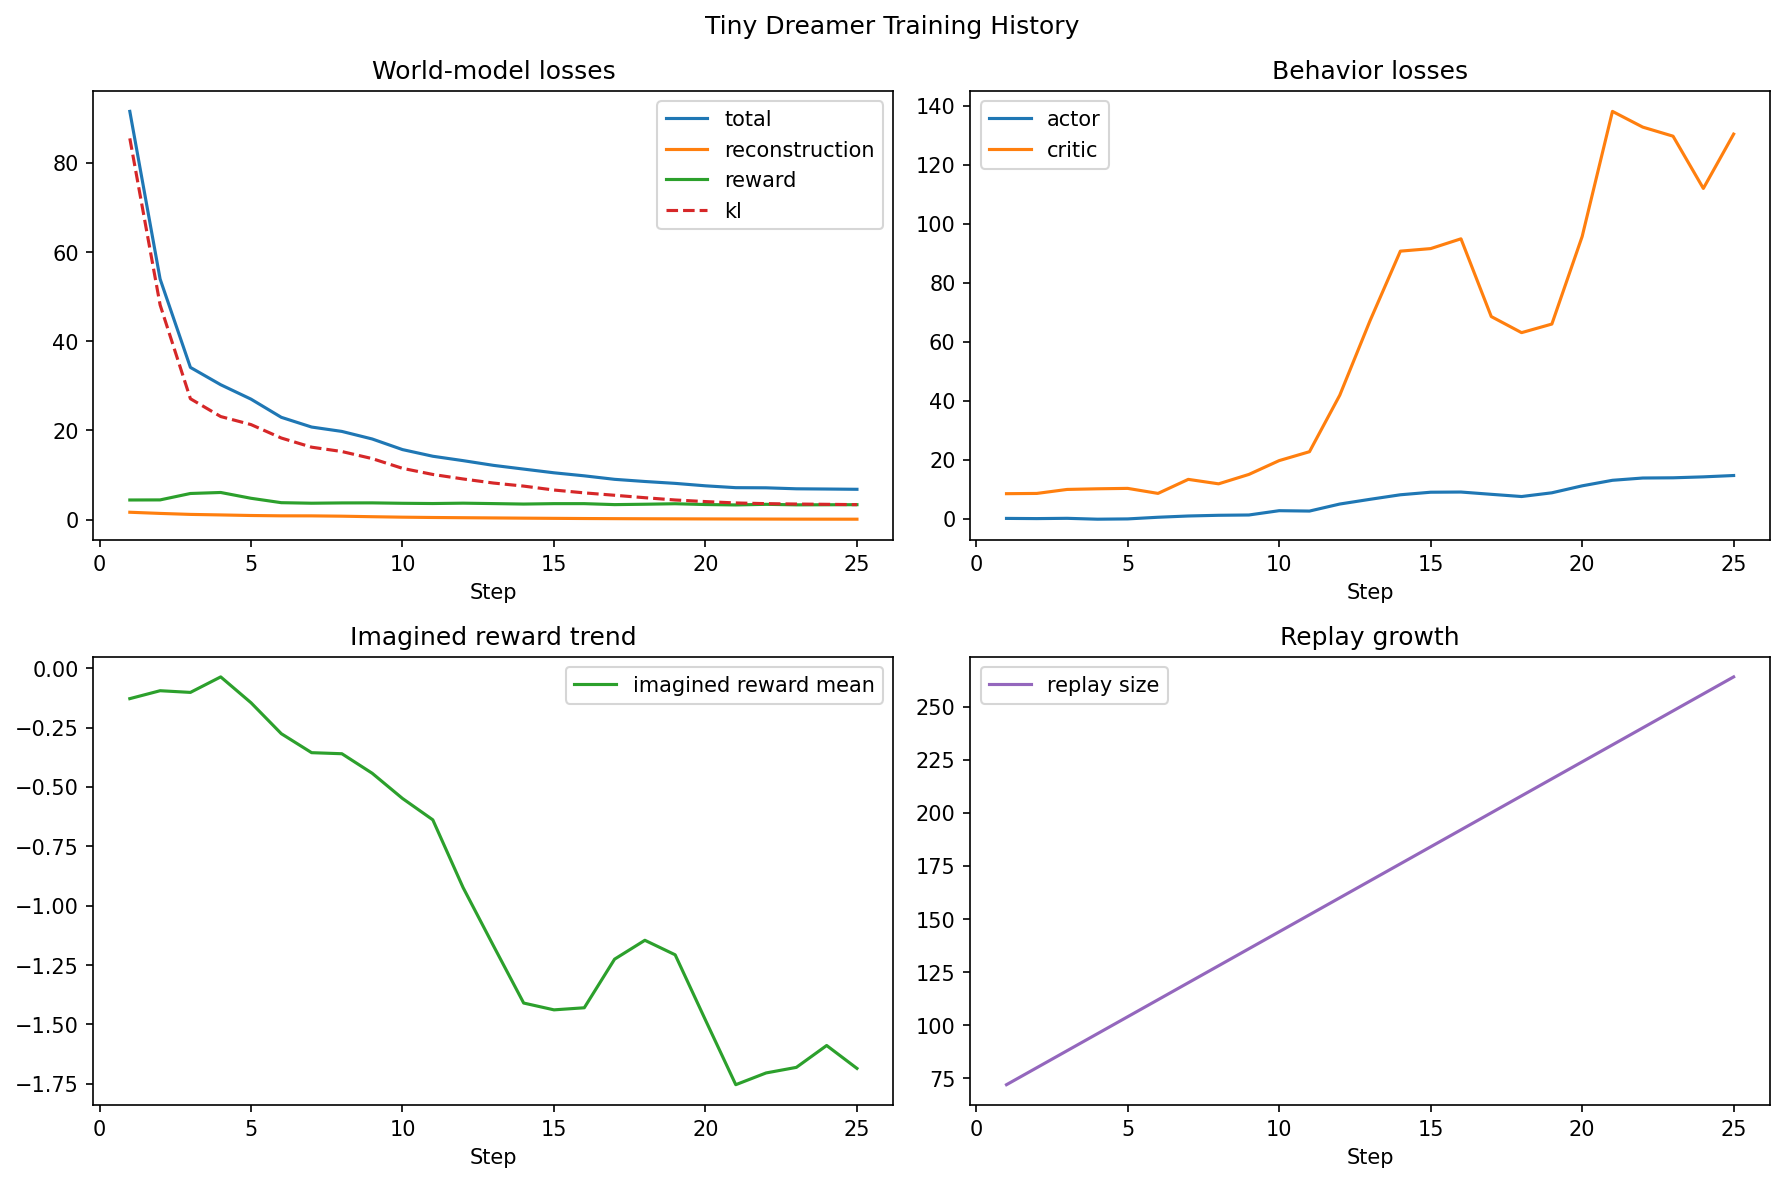

{'summary': PosixPath('/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/sanity_check_001/analysis/sanity_check_001_summary.json'),
 'curves': PosixPath('/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/sanity_check_001/analysis/sanity_check_001_curves.png')}

In [ ]:
from IPython.display import Image, display
import csv
import json
from tiny_dreamer_highway.evaluation import export_training_history_artifacts

analysis_outputs = export_training_history_artifacts(
    training_summary.log_dir / 'cycle_metrics.csv',
    RUN_ARTIFACT_ROOT / 'analysis',
    prefix=RUN_NAME,
)

display(Image(filename=str(analysis_outputs['curves'])))
analysis_summary = json.loads(analysis_outputs['summary'].read_text(encoding='utf-8'))
with metrics_csv_path.open('r', encoding='utf-8', newline='') as handle:
    metric_rows = list(csv.DictReader(handle))
latest_metrics_row = metric_rows[-1]
{
    'analysis_outputs': {
        'curves': str(analysis_outputs['curves']),
        'summary': str(analysis_outputs['summary']),
    },
    'analysis_summary': analysis_summary,
    'phase4_metrics': {
        'world_model/overshooting_kl_loss': latest_metrics_row.get('world_model/overshooting_kl_loss'),
        'world_model/overshooting_feature_mse': latest_metrics_row.get('world_model/overshooting_feature_mse'),
        'world_model/overshooting_pairs': latest_metrics_row.get('world_model/overshooting_pairs'),
        'evaluation/mean_reward': latest_metrics_row.get('evaluation/mean_reward'),
        'evaluation/crash_rate': latest_metrics_row.get('evaluation/crash_rate'),
    },
}

## Agent Driving Demo

Record a short GIF showing the trained policy driving in the real highway-env. The checkpoint from the run above is used to load the actor and world model, then the agent is rolled out for a few episodes.

Using demo recorder from: tiny_dreamer_highway.evaluation.policy_rollout
[demo] episode 1/10 | steps=1 | reward=-3.01 | CRASH | saved sanity_check_001_ep01.gif
[demo] episode 2/10 | steps=2 | reward=-2.25 | CRASH | saved sanity_check_001_ep02.gif
[demo] episode 3/10 | steps=3 | reward=-1.59 | CRASH | saved sanity_check_001_ep03.gif
[demo] episode 4/10 | steps=4 | reward=-0.57 | CRASH | saved sanity_check_001_ep04.gif
[demo] episode 5/10 | steps=1 | reward=-3.01 | CRASH | saved sanity_check_001_ep05.gif
[demo] episode 6/10 | steps=2 | reward=-2.21 | CRASH | saved sanity_check_001_ep06.gif
[demo] episode 7/10 | steps=2 | reward=-2.27 | CRASH | saved sanity_check_001_ep07.gif
[demo] episode 8/10 | steps=3 | reward=-1.32 | CRASH | saved sanity_check_001_ep08.gif
[demo] episode 9/10 | steps=2 | reward=-2.25 | CRASH | saved sanity_check_001_ep09.gif
[demo] episode 10/10 | steps=2 | reward=-2.18 | CRASH | saved sanity_check_001_ep10.gif
[demo] done | avg_reward=-2.07 | summary=sanity_check_00

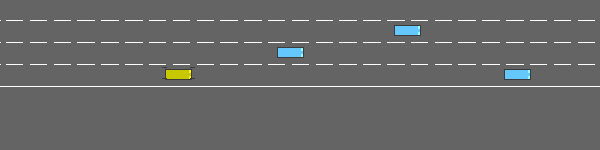


sanity_check_001_ep02.gif


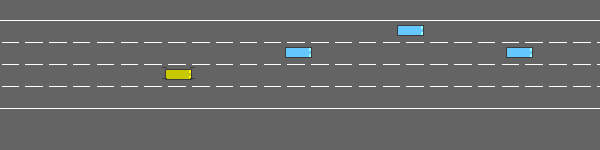


sanity_check_001_ep03.gif


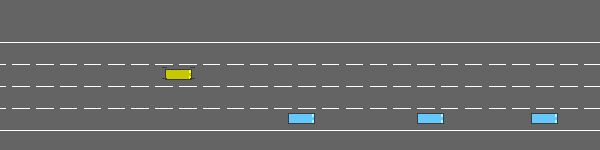


sanity_check_001_ep04.gif


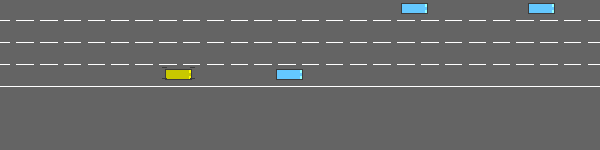


sanity_check_001_ep05.gif


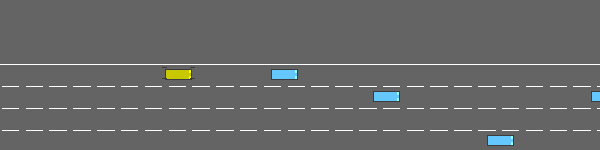


sanity_check_001_ep06.gif


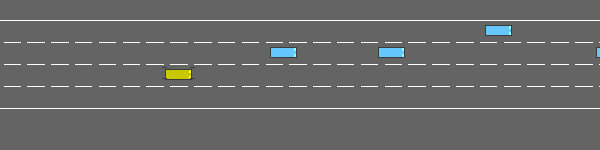


sanity_check_001_ep07.gif


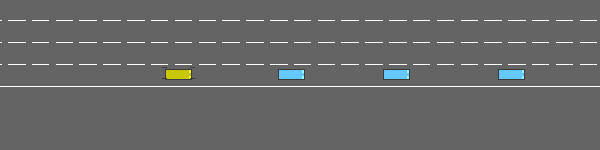


sanity_check_001_ep08.gif


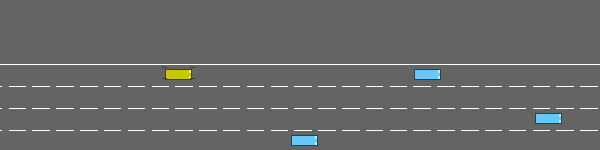


sanity_check_001_ep09.gif


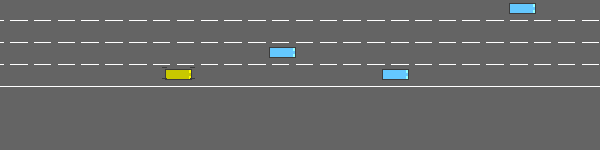


sanity_check_001_ep10.gif


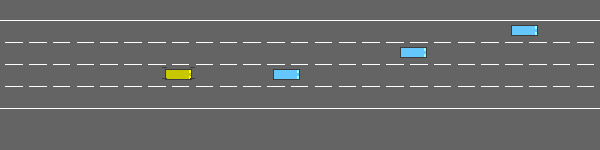

In [18]:
from IPython.display import Image, display
import importlib
import tiny_dreamer_highway.evaluation as evaluation_pkg

try:
    evaluation_pkg = importlib.reload(evaluation_pkg)
    record_demo_videos = evaluation_pkg.record_demo_videos
except (AttributeError, ImportError):
    from tiny_dreamer_highway.evaluation.policy_rollout import record_demo_videos

print('Using demo recorder from:', record_demo_videos.__module__)

demo_outputs = record_demo_videos(
    config,
    checkpoint_path=training_summary.latest_checkpoint,
    output_dir=RUN_ARTIFACT_ROOT / 'demo_videos',
    num_episodes=10,
    max_steps=100,
    fps=15,
    seed=config.seed,
    prefix=RUN_NAME,
    device=config.device,
)

for gif_path in demo_outputs.video_paths:
    print(f'\n{gif_path.name}')
    display(Image(filename=str(gif_path)))